In [1]:
%pip install tensorflow
%pip uninstall -y numpy
%pip install --force-reinstall "scipy==1.11.4" "scikit-learn==1.5.2"
%pip install --no-cache-dir "numpy==1.26.4"


  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
manim 0.17.3 requires numpy<2.0,>=1.19, but you have numpy 2.4.6 which is incompatible.
moderngl-window 2.4.4 requires numpy<2,>=1.16, but you have numpy 2.4.6 which is incompatible.
scipy 1.11.4 requires numpy<1.28.0,>=1.21.6, but you have numpy 2.4.6 which is incompatible.

[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: C:\Users\GuiGui\scoop\apps\python\current\python.exe -m pip install --upgrade pip


Found existing installation: numpy 2.4.6
Uninstalling numpy-2.4.6:
  Successfully uninstalled numpy-2.4.6
Note: you may need to restart the kernel to use updated packages.
  Using cached scipy-1.11.4-cp311-cp311-win_amd64.whl (44.1 MB)
  Using cached scikit_learn-1.5.2-cp311-cp311-win_amd64.whl (11.0 MB)
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
  Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.7.0
    Uninstalling threadpoolctl-3.7.0:
      Successfully uninstalled threadpoolctl-3.7.0
  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 3.1.2
    Uninstalling cloudpickle-3.1.2:
      Successfully uninstalled cloudpickle-3.1.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.11.4
    Uninstalling scipy-1.11.4:

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ml-dtypes 0.6.0 requires numpy>=2.0.0, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: C:\Users\GuiGui\scoop\apps\python\current\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 26.2.1
[notice] To update, run: C:\Users\GuiGui\scoop\apps\python\current\python.exe -m pip install --upgrade pip


In [ ]:
%pip install pillow
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the 'C:\Program Files\Python39\python.exe -m pip install --upgrade pip' command.


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

train_dir = "./data/cats_and_dogs_filtered/train"
print(os.listdir(train_dir))

#number of images in each class
cats_dir = os.path.join(train_dir, "cats")
dogs_dir = os.path.join(train_dir, "dogs")

print("Number of cat images:", len(os.listdir(cats_dir)))
print("Number of dog images:", len(os.listdir(dogs_dir)))

#split 80/20
datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)
test_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=42
)

print("Classes:", train_generator.class_indices)

images, labels = next(train_generator)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

['cats', 'dogs']
Number of cat images: 1000
Number of dog images: 1000
Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Classes: {'cats': 0, 'dogs': 1}
Images shape: (32, 150, 150, 3)
Labels shape: (32,)


parameter : 
image size 150x150 - standard in the industries

Step 3 : build your CNN Model

In [5]:
from tensorflow.keras import datasets, layers, models

model = models.Sequential([
    
    layers.Input(shape=(150, 150, 3)),
    
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),  
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Conv2D(filters=256, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(1, activation='sigmoid')
])

model.summary()

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,994,305 (7.61 MB)

 Trainable params: 1,994,305 (7.61 MB)

 Non-trainable params: 0 (0.00 B)

Step 4: Train the Model

In [6]:
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=100,
    class_mode="binary",
    subset="training",
    shuffle=True,
    seed=42
)

test_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=100,
    class_mode="binary",
    subset="validation",
    shuffle=False,
    seed=42
)

# Train the model for 10 epochs
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 701ms/step - accuracy: 0.5013 - loss: 0.6973 - val_accuracy: 0.5000 - val_loss: 0.6911
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 766ms/step - accuracy: 0.5119 - loss: 0.6919 - val_accuracy: 0.5075 - val_loss: 0.6923
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 818ms/step - accuracy: 0.5475 - loss: 0.6842 - val_accuracy: 0.6275 - val_loss: 0.6745
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 847ms/step - accuracy: 0.6181 - loss: 0.6565 - val_accuracy: 0.6350 - val_loss: 0.6399
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 894ms/step - accuracy: 0.6506 - loss: 0.6214 - val_accuracy: 0.6775 - val_loss: 0.5977
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 911ms/step - accuracy: 0.6906 - loss: 0.5877 - val_accuracy: 0.7075 - val_loss: 0.5531
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 953ms/step - accuracy: 0.7256 - loss: 0.5503 - val_accuracy: 0.7000 - val_loss: 0.5604
Epoch 8/10
16/

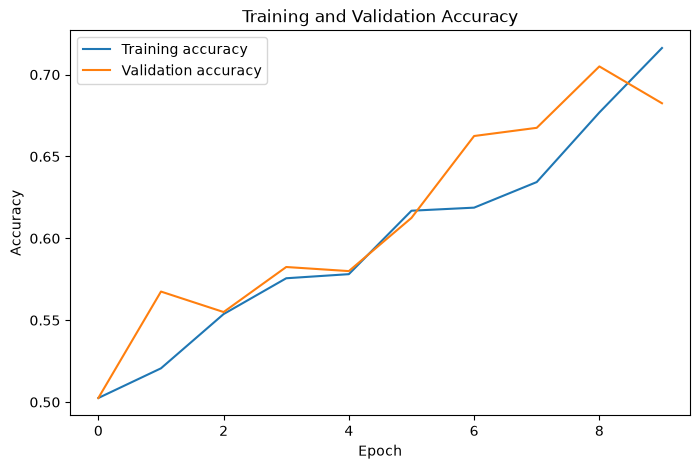

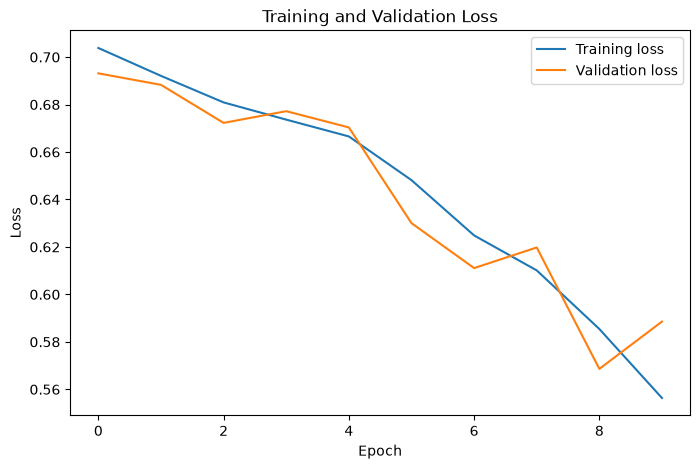

In [28]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

Step 5

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - accuracy: 0.7025 - loss: 0.5753
Test loss: 0.5753
Test accuracy: 0.7025
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 264ms/step


NameError: name 'plt' is not defined

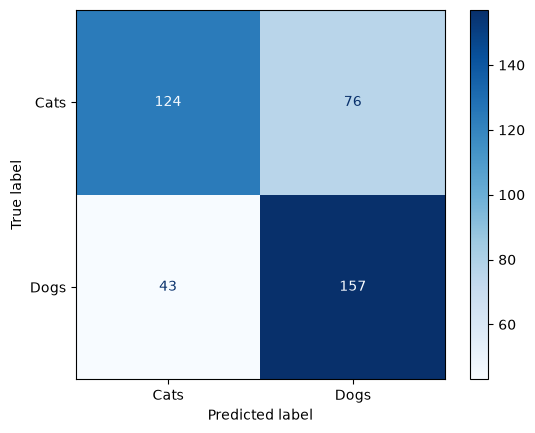

In [ ]:
import matplotlib as plt
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
    
)

test_generator.reset()

# Evaluate model
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))


y_true = test_generator.classes


test_generator.reset()
y_prob = model.predict(test_generator, verbose=1).ravel()
y_pred = (y_prob >= 0.5).astype(int)

# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cats", "Dogs"]
)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()


accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")